In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

## Magnetfeld Kalibration

6.1 0.19999999999999998
13.4 0.3741657386773941
19.5 0.31622776601683794
22.4 0.58309518948453
24.1 0.2
25.4 0.3741657386773941


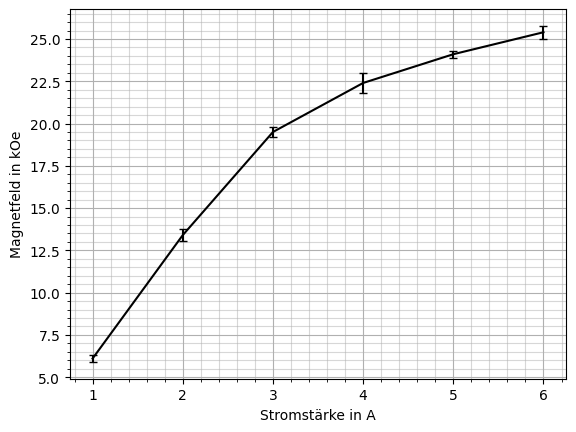

In [2]:
# Magnetfelddaten aus dem Laborbuch
H = np.array(
    [[6, 6, 6, 6.5, 6],     # 1A
    [13,14,13,13.5,13.5],   # 2A
    [19,20,19.5,19.5,19.5], # 3A
    [22,23,22.5,23,21.5],   # 4A
    [24,24,24,24,24.5],     # 5A
    [25,25.5,25.5,25,26]]  # 6A
)                           # H in kOe

I = np.array([1, 2, 3, 4, 5, 6]) # A
Hm = []
Hstd = []
for i in I-1: # um zu indizieren
    mean = np.mean(H[i,:])
    std = np.std(H[i,:], mean=mean)
    print(mean, std)
    Hm.append(mean)
    Hstd.append(std)


fig, ax = plt.subplots()
ax.errorbar(I, Hm, Hstd, fmt='k', capsize=3)

ax.set_xlabel('Stromstärke in A')
ax.set_ylabel('Magnetfeld in kOe')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

## Neonspektrum

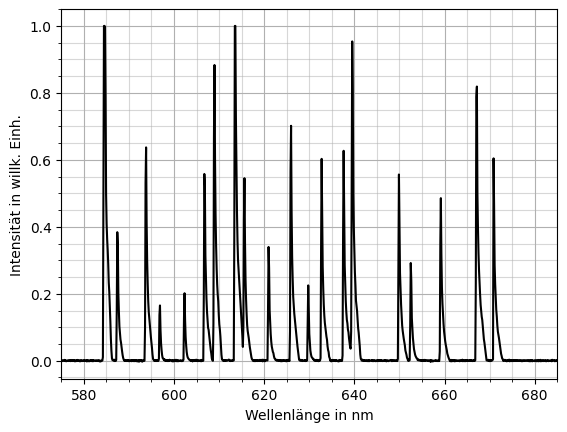

In [3]:
nm = np.loadtxt('../Messdaten/15122025_Zeeman/Spektrum_ThorLabs_2.csv', delimiter=',', skiprows=33, max_rows=3681-33)


fig, ax = plt.subplots()
ax.plot(nm[:,0], nm[:,1], 'k')

ax.set_xlabel('Wellenlänge in nm')
ax.set_ylabel('Intensität in willk. Einh.')

ax.set_xlim(575, 685)
ax.minorticks_on()

ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

In [4]:
dict = {
    9520: '585.2',
    9970: '588.1',
    10920: '594.4',
    12950: '607.4',
    13260: '609.6',
    14010: '614.3',
    14330: '616.3',
    15900: '626.6',
    17700: '638.2',
    16940: '632.8',
    18000: '640.2',
    19600: '650.6',
    22250: '667.8'
}

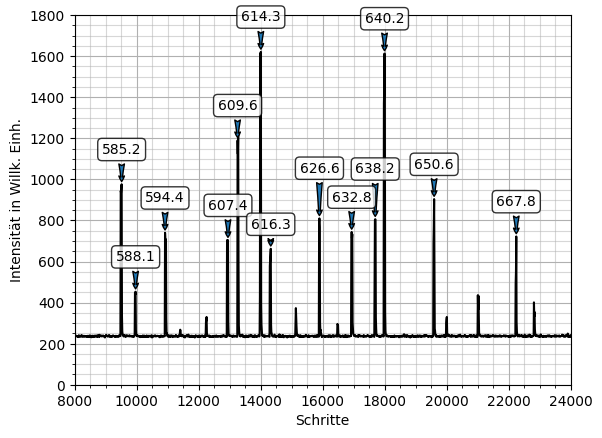

In [5]:
schritt = np.loadtxt('../Messdaten/15122025_Zeeman/schrittspektrum_500ms_win200_step10.dat', delimiter='\t')

fig, ax = plt.subplots()
ax.plot(schritt[:,0], schritt[:,1], 'k')

ax.set_xlabel("Schritte")
ax.set_ylabel("Intensität in Willk. Einh.")
ax.minorticks_on()

ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlim(8000, 24000)
ax.set_ylim(0,1800)

for step in list(dict):
    index = np.where(schritt[:,0] == step)
    y = schritt[index][0][1]
    if step == 14330:
        yt = y + 100
    elif step == 15900:
        yt = y+225
    elif step == 16940:
        yt = y + 150
    elif step == 17700:
        yt = y+225
    else:
        yt = y+150
    ax.annotate(dict[step], (step, y), (step, yt), arrowprops={'arrowstyle': 'fancy'}, ha='center', bbox={'boxstyle':'round', 'alpha':0.8, 'fc':'white', 'ec':'black'})

plt.show()

-80802.68276300769 186.3342303754636
154.3436630018088 0.299890904574692


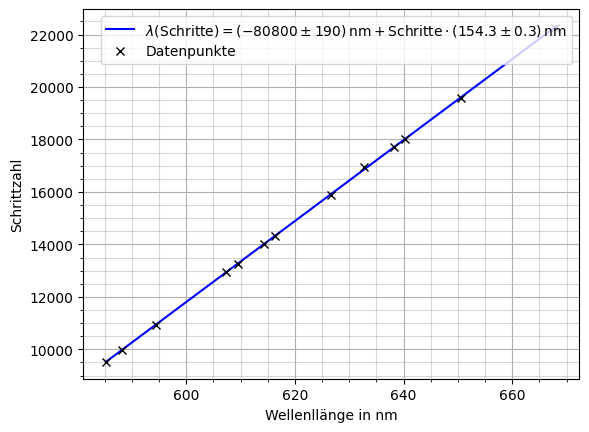

In [6]:
for key in dict:
    dict[key] = float(dict[key])

fig, ax = plt.subplots()


# fit
fit = linregress(list(dict.values()), list(dict))
slope, intercept, stderr, istderr = fit.slope, fit.intercept, fit.stderr, fit.intercept_stderr
print(intercept, istderr)
print(slope, stderr)

x = np.arange(min(list(dict.values())), max(list(dict.values()))+1)
label = r'$\lambda(\text{Schritte})=(-80800\pm190)\,\text{nm}+\text{Schritte}\cdot(154.3\pm0.3)\,\text{nm}$'
ax.plot(x, intercept + slope*x, 'b', label=label)

ax.plot(list(dict.values()), list(dict), 'xk', label='Datenpunkte')

ax.legend()

ax.set_xlabel('Wellenllänge in nm')
ax.set_ylabel('Schrittzahl')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
plt.show()

# Laserspektrum?

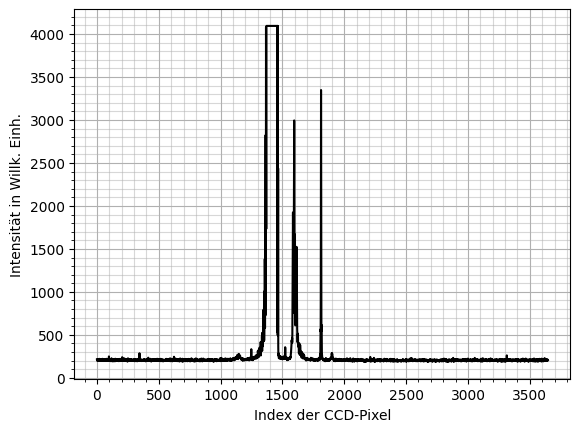

In [7]:
#laser = np.loadtxt('../Messdaten/15122025_Zeeman/500ms_Linsenjustage.dat', delimiter='\t')
longi = np.loadtxt('../Messdaten/15122025_Zeeman/500mslongitudinalemoden_gesehen.dat', delimiter='\t')
#gesehen = np.loadtxt('../Messdaten/15122025_Zeeman/Laser_gesehen.dat', delimiter='\t')


fig, ax = plt.subplots()
ax.plot(longi[:,0], longi[:,1], 'k', label='Longitudinalmoden')


ax.set_xlabel("Index der CCD-Pixel")
ax.set_ylabel("Intensität in Willk. Einh.")

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

## Variation der Spaltbreite

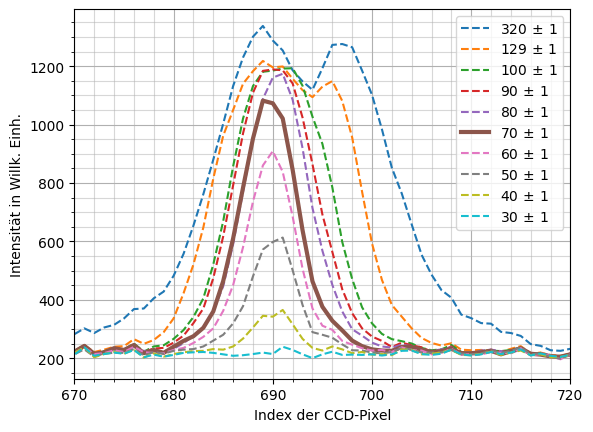

In [8]:
breiten = [320, 129, 100, 90, 80, 70, 60, 50 , 40, 30]

fig, ax = plt.subplots()

for breite in breiten:
    data = np.loadtxt(f'../Messdaten/15122025_Zeeman/6_dx_{breite}.dat', delimiter='\t')
    data[:,0]
    if breite != 70:
        ax.plot(data[:,0], data[:,1], '--', label=str(breite)+r'$\,\pm\,$1')
    else:
        ax.plot(data[:,0], data[:,1], '-', label=str(breite)+r'$\,\pm\,$1', lw=3)

ax.legend()
ax.set_xlabel("Index der CCD-Pixel")
ax.set_ylabel("Intensität in Willk. Einh.")
ax.set_xlim(670, 720)
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
plt.show()

## Polarisation der CCD

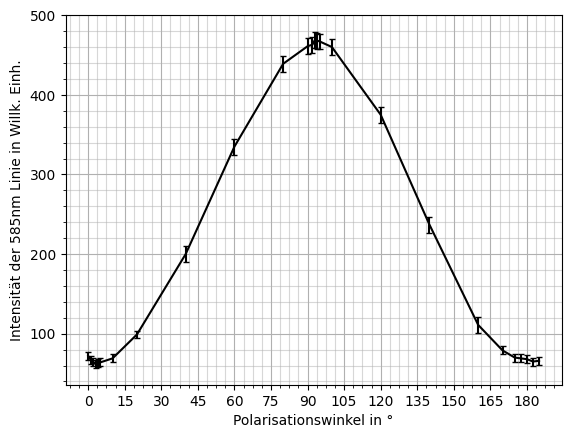

In [9]:
pol = {
0: 72,
1: 67,
2: 65,
3: 62,
4: 63,
5: 64,
10: 69,
20: 99,
40: 200,
60: 335,
80: 439,
90: 461,
92: 463,
93: 469,
94: 468,
95: 467,
100: 460,
120: 375,
140: 237,
160: 111,
170: 79,
175: 70,
177.5: 69,
180: 68,
182.5: 65,
185: 66
}
yerr = 8*[5]+12*[10]+6*[5]

fig, ax = plt.subplots()
ax.errorbar(list(pol), list(pol.values()), yerr=yerr, fmt='-k', capsize=2)

xticks = [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180]
xlabels= [str(tick) for tick in xticks]
ax.set_xticks(xticks, labels=xlabels)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Polarisationswinkel in °')
ax.set_ylabel('Intensität der 585nm Linie in Willk. Einh.')

plt.show()

## $\lambda/2$-Plättchen

In [10]:
pol90 = """0 	367
1 	348
2 	342
3 	347
4 	340
5 	340
10 	296
15 	250
20 	201
25 	144
30 	100
35 	61
40 	50
41 	52
42 	49
43 	53
44 	49
45 	54
46 	53
47 	56
48 	60
49 	60
50 	63
55 	95
65 	201
75 	304
80 	343
82 	351
84 	360
85 	366
86 	359
87 	368
88 	355
89 	372
90 	354"""

pol0 = """0 	41
1 	47
2 	50
3 	53
4 	58
5 	58
10 	81
20 	176
30 	264
40 	320
41 	324
42 	324
43 	323
44 	323
45 	323
50 	304
60 	223
70 	125
80 	52
85 	47
86 	43
87 	43
88 	41
89 	43
90 	44"""

pol90 = {int(x[0]):int(x[1]) for x in [y.split() for y in pol90.split('\n')]}
pol0 = {int(x[0]):int(x[1]) for x in [y.split() for y in pol0.split('\n')]}

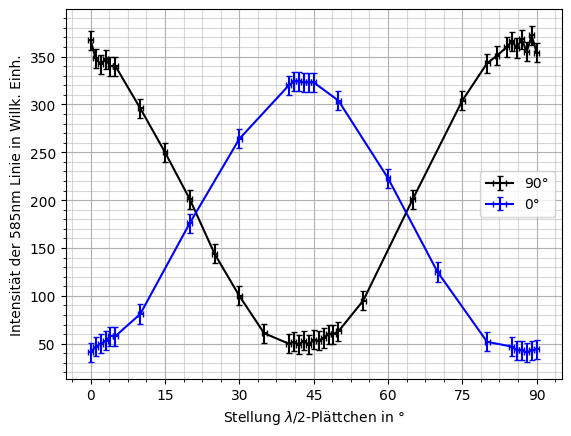

In [11]:
fig, ax = plt.subplots()
ax.errorbar(list(pol90), list(pol90.values()), yerr=10, xerr=0.5, fmt='-k', capsize=2, label='90°')
ax.errorbar(list(pol0), list(pol0.values()), yerr=10, xerr=0.5, fmt='-b', capsize=2, label='0°')

xticks = [0, 15, 30, 45, 60, 75, 90]
xlabels= [str(tick) for tick in xticks]
ax.set_xticks(xticks, labels=xlabels)

ax.set_xlabel(r'Stellung $\lambda/2$-Plättchen in °')
ax.set_ylabel('Intensität der 585nm Linie in Willk. Einh.')

ax.legend()
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

## Kalibration der CCD für 585.2 nm und 616 nm Linien

{9520: 585.2, 9970: 588.1, 10920: 594.4, 12950: 607.4, 13260: 609.6, 14010: 614.3, 14330: 616.3, 15900: 626.6, 17700: 638.2, 16940: 632.8, 18000: 640.2, 19600: 650.6, 22250: 667.8}


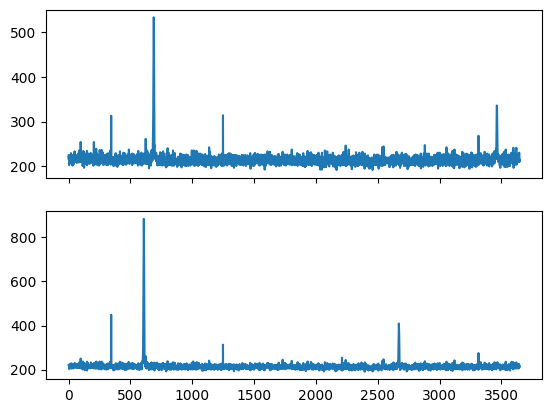

In [12]:
print(dict)

dat1 = np.loadtxt('../Messdaten/15122025_Zeeman/9_0deg_0A.dat', delimiter='\t')# im '9' Bild sind die 585.2 und 588.1nm Linien
dat2 = np.loadtxt('../Messdaten/15122025_Zeeman/10_0deg_0A.dat', delimiter='\t')# im '10' Bild sind die 614 und 616

fig, (ax1, ax2) = plt.subplots(2,1,sharex=True)

ax1.plot(dat1[:,0], dat1[:,1])
ax2.plot(dat2[:,0], dat2[:,1])

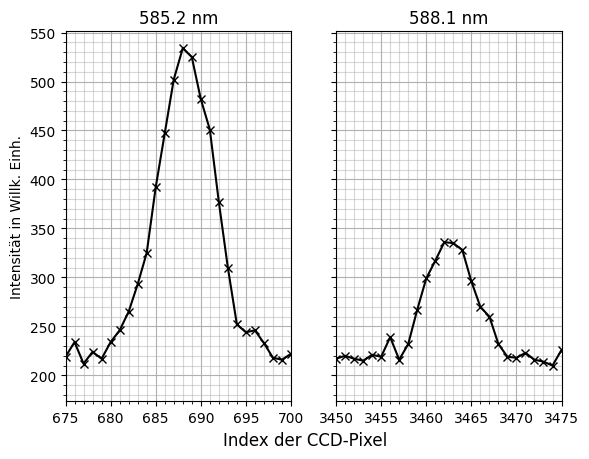

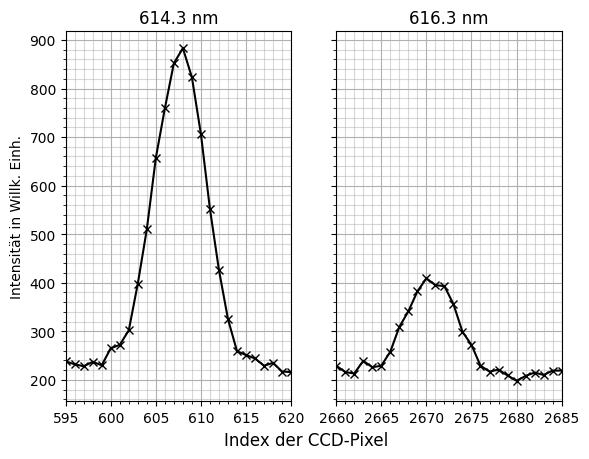

In [13]:
first = True
for dat in [dat1, dat2]:

    fig, (ax1, ax2) = plt.subplots(1,2,sharey=True)

    ax1.plot(dat[:,0], dat[:,1], 'x-k') # use dat2 to check if they split. only then are they lines not dead pxiels
    ax2.plot(dat[:,0], dat[:,1], 'x-k')
    if first == True:
        ax1.set_title('585.2 nm')
        ax2.set_title('588.1 nm')
        ax1.set_xlim(675, 700)
        ax2.set_xlim(3450, 3475)
        first = False
    else:
        ax1.set_title('614.3 nm')
        ax2.set_title('616.3 nm')
        ax1.set_xlim(595, 620)
        ax2.set_xlim(2660, 2685)

    ax1.set_ylabel('Intensität in Willk. Einh.')
    fig.supxlabel('Index der CCD-Pixel')
    ax1.minorticks_on()
    ax1.grid(which='major')
    ax1.grid(which='minor', alpha=0.5)
    ax2.minorticks_on()
    ax2.grid(which='major')
    ax2.grid(which='minor', alpha=0.5)

0.0010450450450450368 0.0 584.4810090090091 0.0
0.0009699321047526673 0.0 613.7102812803104 0.0


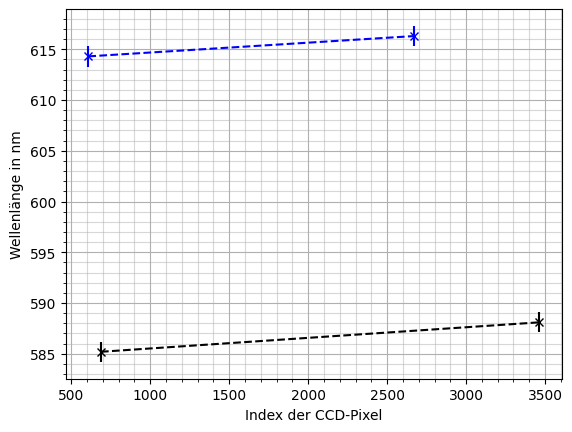

In [14]:
nor = ((688, 3463), (585.2, 588.1))
ano = ((608, 2670), (614.3, 616.3))

#fits
fitno = linregress(nor[0], nor[1])
print(fitno.slope, fitno.stderr, fitno.intercept, fitno.intercept_stderr)

fitano = linregress(ano[0], ano[1])
print(fitano.slope, fitano.stderr, fitano.intercept, fitano.intercept_stderr)

nox = np.arange(nor[0][0], nor[0][1]+1)
anox = np.arange(ano[0][0], ano[0][1]+1)

fig, ax = plt.subplots()
ax.plot(nox, fitno.intercept+nox*fitno.slope, '--k')
ax.plot(anox, fitano.intercept+anox*fitano.slope, '--b')

ax.errorbar(nor[0], nor[1], yerr=1, fmt='xk')
ax.errorbar(ano[0], ano[1], yerr=1, fmt='xb')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

ax.set_ylabel('Wellenlänge in nm')
ax.set_xlabel('Index der CCD-Pixel')
plt.show()

In [15]:
def nm_axis(line, x_old):
    if line == 585.2:
        pxslope, pxintercept = 0.0010450450450450368, 584.4810090090091
    elif line == 614.3:
        pxslope, pxintercept = 0.0009699321047526673, 613.7102812803104
    else:
        print(f'{line} nm line not recognized')
    x_new = []
    for x in x_old:
        x_new.append(pxintercept + x * pxslope)
    return np.array(x_new)

## Linienspektren

585.2nm, 0deg, 0.0 kOe: µ=585.2003295575486, HWB=0.012636234255237116, y0=36.642100819546314
585.2nm, 0deg, 6.1 kOe, left: µ=585.1892116881788(0.0002035400175195277) nm, HWB=0.01740960759382837(0.0006671402340318767) nm, y0=16.408248375626997(8.942860732591821) WE
585.2nm, 0deg, 6.1 kOe, right: µ=585.2114468568362(0.0004266990296064796) nm, HWB=0.020232400534684326(0.0012030816310965768) nm, y0=57.196645607158224(12.454486238941003) WE
585.2nm, 0deg, 13.4 kOe, left: µ=585.1785599721572(0.0003973395419786113) nm, HWB=0.02244022019738038(0.001339695362925599) nm, y0=55.09700250312439(11.624693447341249) WE
585.2nm, 0deg, 13.4 kOe, right: µ=585.2221702975352(0.00026041408295047054) nm, HWB=0.020420795812870787(0.0009348237531467752) nm, y0=43.84622669361509(9.925248512576575) WE
585.2nm, 0deg, 19.5 kOe, left: µ=585.1679582518658(0.0018153172499906062) nm, HWB=0.03259297972336932(0.005843980095246078) nm, y0=103.45714685572422(29.754689492329835) WE
585.2nm, 0deg, 19.5 kOe, right: µ=585.23

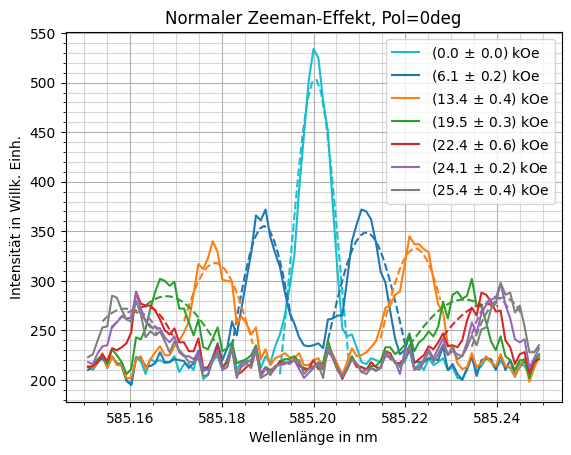

9_45deg_0A.dat not found


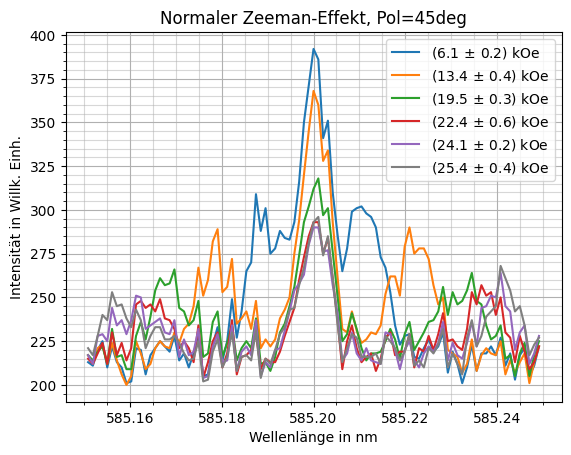

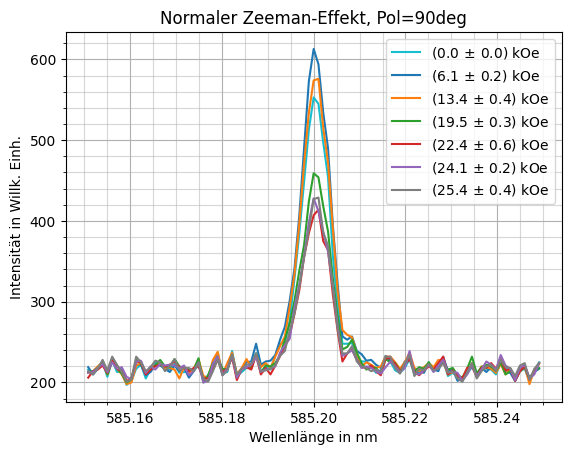

585.2nm, 0deg, 0.0 kOe: µ=614.2996513642228, HWB=0.007949485013081752, y0=124.29158410966915
585.2nm, 0deg, 6.1 kOe, left: µ=614.2896327247145(0.0002519418235867086) nm, HWB=0.01896582124192472(0.0006417898414970574) nm, y0=107.41073525875098(6.5522869726764705) WE
585.2nm, 0deg, 6.1 kOe, right: µ=614.3098159843453(0.0003425066305783113) nm, HWB=0.019151415156507104(0.0008364286943707087) nm, y0=115.41202195823308(8.537178237908206) WE
585.2nm, 0deg, 13.4 kOe, left: µ=614.2819891309002(0.0008257477021391988) nm, HWB=0.036070691105331294(0.001922774977129365) nm, y0=175.85595496742596(6.28604614069343) WE
585.2nm, 0deg, 13.4 kOe, right: µ=614.3174752413219(0.000838094441632078) nm, HWB=0.03311615613994683(0.0018271489376495388) nm, y0=173.33063202540663(6.923256461809034) WE
585.2nm, 0deg, 19.5 kOe, left: µ=614.2731570438942(0.0007402227250918586) nm, HWB=0.0445078080589995(0.002260072856586492) nm, y0=177.77092743041578(4.8004005903683336) WE
585.2nm, 0deg, 19.5 kOe, right: µ=614.32606

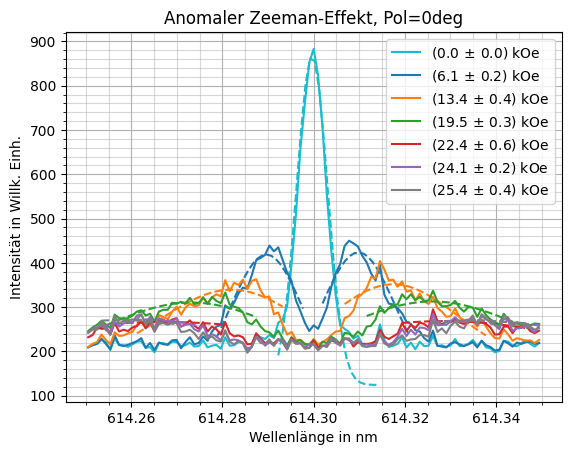

585.2nm, 90deg, 0.0 kOe: µ=614.3002226859026, HWB=0.007128984875885558, y0=111.99658597786262
585.2nm, 90deg, 6.1 kOe, left: µ=614.2975667683542(0.00023578292359804822) nm, HWB=0.011273728332800626(0.000321369002445745) nm, y0=96.15898147419976(14.360670541168092) WE
585.2nm, 90deg, 6.1 kOe, right: µ=614.3020308239574(0.000706984474855677) nm, HWB=0.012849616207329023(0.0007752181331956113) nm, y0=155.4468604964229(29.136849116581686) WE
585.2nm, 90deg, 13.4 kOe, left: µ=614.2935191400261(0.00019032300319242416) nm, HWB=0.015242419667856028(0.0004502352131499907) nm, y0=101.8331797938352(7.553342060047028) WE
585.2nm, 90deg, 13.4 kOe, right: µ=614.3069032941003(0.0003427454378720693) nm, HWB=0.015861060562311728(0.0008081352158610024) nm, y0=110.51762627581637(12.358507748977805) WE
585.2nm, 90deg, 19.5 kOe, left: µ=614.290414065708(0.0003157464239853901) nm, HWB=0.020431850866165228(0.0008597621844973433) nm, y0=112.81178110821142(7.7832846992434614) WE
585.2nm, 90deg, 19.5 kOe, right

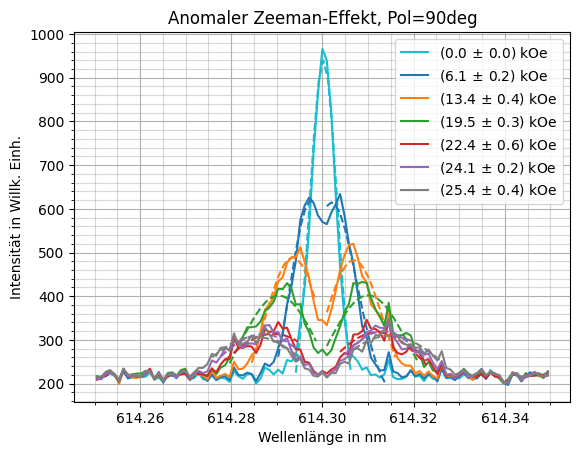

In [106]:
from scipy.optimize import curve_fit

def gaussian(x, mu, sig, y0):
    return (1/sig*np.sqrt(2*np.pi))*np.exp(-(x-mu)**2/(2*sig**2))+y0

curs = ['0A', '1A', '2A', '3A', '4A', '5A', '6A']
colors = ['tab:cyan', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:grey']

mags = [(00.0, 0.0),
        (06.1, 0.2),
        (13.4, 0.4),
        (19.5, 0.3),
        (22.4, 0.6),
        (24.1, 0.2),
        (25.4, 0.4)] # gerundete Magnetfelder + std für 0 bis 6 Ampère

filenames = ['9_0deg', '9_45deg', '9_90deg', '10_0deg', '10_90deg'] # dreimal normal, zweimal anomal

for filename in filenames:
    fig, ax = plt.subplots()

    # plot aufhübschen
    ax.set_xlabel('Wellenlänge in nm')
    ax.set_ylabel('Intensität in Willk. Einh.')
    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)

    # Titel setzen
    pol = filename.split('_')[1]
    if filename[0] == '9':
        ax.set_title(f'Normaler Zeeman-Effekt, Pol={pol}')
    else:
        ax.set_title(f'Anomaler Zeeman-Effekt, Pol={pol}')
    
    #einzelne Linien in Plot für jedes Magnetfeld
    for i, cur in enumerate(curs):
        color = colors[i] # damit jede Linie fürs gleiche Magnetfeld die gleiche Farbe hat
        try:
            data = np.loadtxt(f'../Messdaten/15122025_Zeeman/{filename}_{cur}.dat', delimiter='\t')
        except:
            print(f'{filename}_{cur}.dat not found')
            continue

        # change to wavelength
        if filename[0] == '9':
            line = 585.2
            wave_x = nm_axis(line, data[:,0])
        else:
            line = 614.3
            wave_x = nm_axis(line, data[:,0])

        maska = np.where(wave_x >= line-0.05) # Daten einkürzen macht fitten leichter,
        wave_x = wave_x[maska]                # weil dann nicht auf die falschen Peaks + noise gefittet wird
        wave_y = data[:,1][maska]
        maskb = np.where(wave_x <= line+0.05)
        wave_x = wave_x[maskb] # arrays bestehen nur noch aus interessantem Bereich
        wave_y = wave_y[maskb]
        
        if filename[0] == '9':
            ax.plot(wave_x, wave_y, label=f'({mags[i][0]}'+r'$\,\pm\,$'+f'{mags[i][1]}) kOe', color=color)
            thresh = 244
        else:
            thresh = 255
            ax.plot(wave_x, wave_y, label=f'({mags[i][0]}'+r'$\,\pm\,$'+f'{mags[i][1]}) kOe', color=color)
        
        # Gauss fits
        if pol == '90deg' and filename[0] == '9':
            continue
        elif pol == '45deg':
            continue
        else:
            fit_mask = np.where(wave_y > thresh)
            fitx = wave_x[fit_mask]
            fity = wave_y[fit_mask]
            plotfitx = np.arange(min(fitx), max(fitx), 0.001)
            if cur == '0A':
                guess = [line, 0.02, 30]
                popt, pcov = curve_fit(gaussian, fitx, fity, guess)
                print(f"585.2nm, {pol}, {mags[i][0]} kOe: µ={popt[0]}, HWB={2*np.sqrt(2*np.log(2))*popt[1]}, y0={popt[2]}")
                ax.plot(plotfitx, gaussian(plotfitx, *popt), '--', color=color)
            else:
                sep_left = np.where(fitx<line)
                sep_right = np.where(fitx>line)

                fitx_left = fitx[sep_left]
                plotfitx_left = np.arange(min(fitx_left), max(fitx_left), 0.001)
                fity_left = fity[sep_left]
                guess_left = [line-0.03, 0.02, 217]
                popt_left, pcov_left = curve_fit(gaussian, fitx_left, fity_left, guess_left)
                perr_left = np.sqrt(np.diag(pcov_left))
                ax.plot(plotfitx_left, gaussian(plotfitx_left, *popt_left), '--', color=color)
                print(f"585.2nm, {pol}, {mags[i][0]} kOe, left: µ={popt_left[0]}({perr_left[0]}) nm, HWB={2*np.sqrt(2*np.log(2))*popt_left[1]}({2*np.sqrt(2*np.log(2))*perr_left[1]}) nm, y0={popt_left[2]}({perr_left[2]}) WE")
                
                fitx_right = fitx[sep_right]
                plotfitx_right = np.arange(min(fitx_right), max(fitx_right), 0.001)
                fity_right = fity[sep_right]
                guess_right = [line+0.03, 0.02, 217]
                popt_right, pcov_right = curve_fit(gaussian, fitx_right, fity_right, guess_right)
                perr_right = np.sqrt(np.diag(pcov_right))
                ax.plot(plotfitx_right, gaussian(plotfitx_right, *popt_right), '--', color=color)
                print(f"585.2nm, {pol}, {mags[i][0]} kOe, right: µ={popt_right[0]}({perr_right[0]}) nm, HWB={2*np.sqrt(2*np.log(2))*popt_right[1]}({2*np.sqrt(2*np.log(2))*perr_right[1]}) nm, y0={popt_right[2]}({perr_right[2]}) WE")
            

    ax.legend()
    plt.show()

## Spezifische Ladung e/m

0.0015871424193533018 2.6875335487189017e-05
168856309233.54984


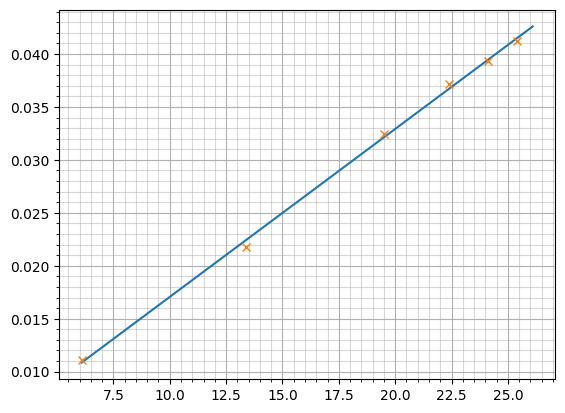

0.001297890920236065 0.0001853192491214054
-472886774219.5961


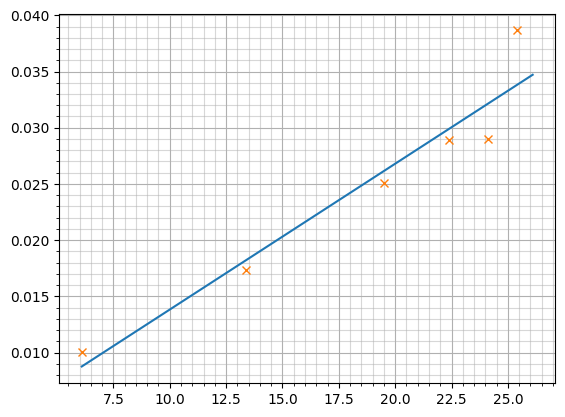

0.0006066253831430323 3.8695473627016704e-05
-221024059974.20734


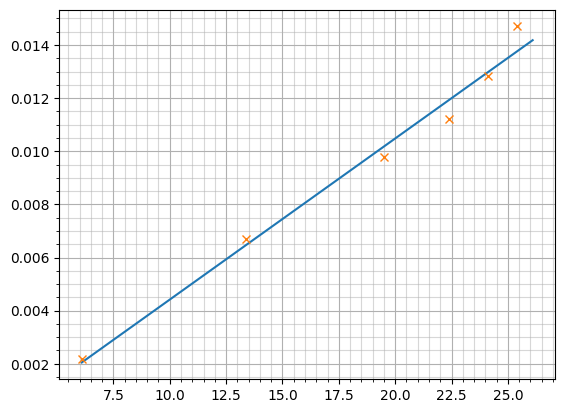

In [94]:
abst = [abs(585.1892116881788-585.2114468568362)/2,
       abs(585.1785599721572-585.2221702975352)/2,
       abs(585.1679582518658-585.232785240565)/2,
       abs(585.1634514046511-585.2377580199542)/2,
       abs(585.1609681564712-585.239655705868)/2,
       abs(585.1588880497595-585.2414266860361)/2] # spektrale Aufspaltung ist Abstand zu unverschobenen Linie

abstano = [abs(614.2897343062978-614.3097716794134)/2,
           abs(614.282893347027-614.3175088113669)/2,
           abs(614.2743067589212-614.324536039715)/2,
           abs(614.2697259808147-614.3274595317971)/2,
           abs(614.2644895929654-614.3225117295966)/2,
           abs(614.2594150917058-614.3367235438473)/2]

abstano2 = [abs(614.2975667683542-614.3018893935262)/2,
            abs(614.2935191400261-614.3068958791623)/2,
            abs(614.2904575181688-614.3100226397281)/2,
            abs(614.2892251895839-614.3116461117803)/2,
            abs(614.2874655756538-614.3131180974274)/2,
            abs(614.2853512626609-614.3147469338337)/2]

import scipy.constants as const

mags = [(06.1, 0.2),
        (13.4, 0.4),
        (19.5, 0.3),
        (22.4, 0.6),
        (24.1, 0.2),
        (25.4, 0.4)]

def spez_ladung(slope, line, j, jj):
    return 4*np.pi*const.c*slope*(1e-9/(1e6/(4*np.pi)))/(line**2*const.mu_0)/(j-jj)

em = linregress([mag[0] for mag in mags], abst)
print(em.slope, em.stderr)
print(spez_ladung(em.slope, 585.2e-9, 1.034, 0))
emx = np.arange(6.1, 26.4)

fig, ax = plt.subplots()

ax.plot(emx, em.intercept+emx*em.slope)

ax.plot([mag[0] for mag in mags], abst, 'x')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
plt.show()


emano = linregress([mag[0] for mag in mags], abstano)
print(emano.slope, emano.stderr)
print(spez_ladung(emano.slope, 614.3e-9, 1.229, 1.503))
emanox = np.arange(6.1, 26.4)

fig, ax = plt.subplots()

ax.plot(emanox, emano.intercept+emanox*emano.slope)

ax.plot([mag[0] for mag in mags], abstano, 'x')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
plt.show()

emano2 = linregress([mag[0] for mag in mags], abstano2)
print(emano2.slope, emano2.stderr)
print(spez_ladung(emano2.slope, 614.3e-9, 1.229, 1.503))
emanox2 = np.arange(6.1, 26.4)

fig, ax = plt.subplots()

ax.plot(emanox2, emano2.intercept+emanox2*emano2.slope)

ax.plot([mag[0] for mag in mags], abstano2, 'x')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
plt.show()